# Understanding ACE SWEPAM Variables

This notebook explores the main plasma variables in the ACE SWEPAM 64-second Level 2 dataset before deciding how to map them to sound. 

In [1]:
from pathlib import Path

import cdflib
import matplotlib.pyplot as plt
import numpy as np

data_path = Path("../data/ac_h0_swe_20240709_v11.cdf")  # Path to the data 
cdf = cdflib.CDF(data_path)  # Load the CDF file

print(f"Loaded: {data_path.name}")

variables = ["Np", "Vp", "Tpr", "V_RTN"]

for variable in variables:
    attributes = cdf.varattsget(variable)  # Get variable attributes

    print(f"Variable: {variable}")
    print("Field name:", attributes.get("FIELDNAM", "N/A"))
    print("Description:", attributes.get("CATDESC", "N/A"))
    print("Units:", attributes.get("UNITS", "N/A"))
    print("Valid min:", attributes.get("VALIDMIN", "N/A"))
    print("Valid max:", attributes.get("VALIDMAX", "N/A"))
    print("Fill value:", attributes.get("FILLVAL", "N/A"))

    times = cdflib.cdfepoch.unixtime(cdf.varget("Epoch"))  # Convert Epoch to Unix time

times = cdflib.cdfepoch.to_datetime(cdf.varget("Epoch"))

def load_clean_variable(cdf_file, variable_name):
    values = np.asarray(cdf_file.varget(variable_name))
    attributes = cdf_file.varattsget(variable_name)

    mask = np.isfinite(values)

    fill_value = attributes.get("FILLVAL")
    if fill_value is not None:
        mask &= values != fill_value

    valid_min = attributes.get("VALIDMIN")
    if valid_min is not None:
        mask &= values >= valid_min

    valid_max = attributes.get("VALIDMAX")
    if valid_max is not None:
        mask &= values <= valid_max

    return times[mask], values[mask], attributes

time_np, density, density_atts = load_clean_variable(cdf, "Np")
time_vp, speed, speed_atts = load_clean_variable(cdf, "Vp")
time_tpr, temperature, temperature_atts = load_clean_variable(cdf, "Tpr")

print("Density samples:", len(density))
print("Speed samples:", len(speed))
print("Temperature samples:", len(temperature))

Loaded: ac_h0_swe_20240709_v11.cdf
Variable: Np
Field name: Proton No. density
Description: Solar Wind Proton Number Density, scalar
Units: #/cc
Valid min: 0.0
Valid max: 200.0
Fill value: -1e+31
Variable: Vp
Field name: Solar Wind Proton Speed
Description: Solar Wind Bulk Speed
Units: km/s
Valid min: 0.0
Valid max: 2000.0
Fill value: -1e+31
Variable: Tpr
Field name: Proton Temperature
Description: radial component of the proton temperature
Units: Kelvin
Valid min: 1000.0
Valid max: 1.1e+06
Fill value: -1e+31
Variable: V_RTN
Field name: Solar Wind Velocity (RTN)
Description: Solar Wind Velocity in RTN coord., 3 components
Units: km/s
Valid min: [   0. -900. -900.]
Valid max: [1800.  900.  900.]
Fill value: -1e+31
Density samples: 482
Speed samples: 1257
Temperature samples: 1212


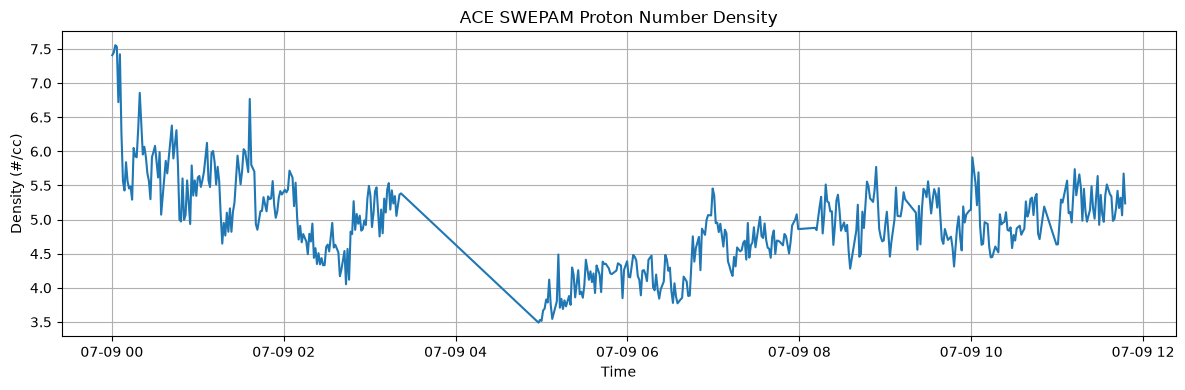

In [2]:
plt.figure(figsize=(12, 4))
plt.plot(time_np, density)
plt.title("ACE SWEPAM Proton Number Density")
plt.xlabel("Time")
plt.ylabel(f"Density ({density_atts.get('UNITS', '')})")
plt.grid(True)
plt.tight_layout()
plt.show()


In [3]:
density = np.asarray(cdf.varget("Np"))
atts = cdf.varattsget("Np")

fill = atts.get("FILLVAL")

print("Fill value:", fill)
print("Number of fill values:", np.sum(density == fill))

Fill value: -1e+31
Number of fill values: 868


In [4]:
invalid_indices = np.where(density == fill)[0]
print("Number of invalid values:", len(invalid_indices))
print(invalid_indices[:20])

Number of invalid values: 868
[ 19  29  33  37  38  41  50  61  81  88  92  96 100 112 117 126 143 147
 151 174]


In [5]:
density = np.asarray(cdf.varget("Np"), dtype=float)
density_atts = cdf.varattsget("Np")
times = cdflib.cdfepoch.to_datetime(cdf.varget("Epoch"))

fill_value = density_atts.get("FILLVAL")
valid_min = density_atts.get("VALIDMIN")
valid_max = density_atts.get("VALIDMAX")

mask = np.isfinite(density)

if fill_value is not None:
    mask &= density != fill_value

if valid_min is not None:
    mask &= density >= valid_min

if valid_max is not None:
    mask &= density <= valid_max

clean_times = times[mask]
clean_density = density[mask]

time_diff = np.diff(clean_times).astype('timedelta64[s]').astype(int)

print("Largest gap:", np.max(time_diff))

Largest gap: 5760


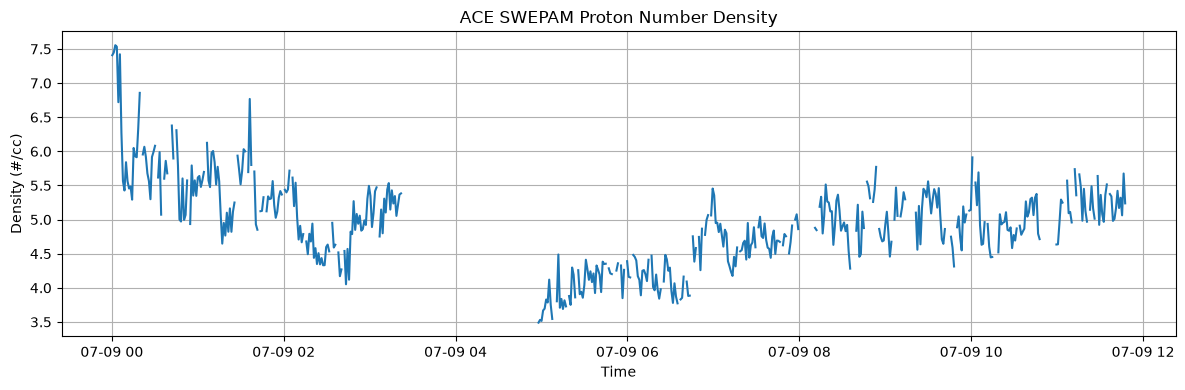

In [6]:
density_plot = density.copy()
density_plot[~mask] = np.nan

plt.figure(figsize=(12, 4))
plt.plot(times, density_plot)
plt.title("ACE SWEPAM Proton Number Density")
plt.xlabel("Time")
plt.ylabel("Density (#/cc)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [7]:
print("Minimum:", np.nanmin(speed))
print("Maximum:", np.nanmax(speed))
print("Mean:", np.nanmean(speed))
print("Standard Deviation:", np.nanstd(speed))


Minimum: 352.83
Maximum: 396.56
Mean: 375.6017
Standard Deviation: 7.7627134


In [8]:
# Invalid values in speed

total_samples = len(speed)
invalid_samples = np.sum(~mask)
valid_samples = np.sum(mask)

print(f"Total samples: {total_samples}")
print(f"Invalid samples: {invalid_samples}")
print(f"Valid samples: {valid_samples}")
print(f"Percentage of invalid samples: {invalid_samples / total_samples * 100:.2f}%")

Total samples: 1257
Invalid samples: 868
Valid samples: 482
Percentage of invalid samples: 69.05%


In [9]:
invalid_indices = np.where(~mask)[0]

gaps = []

if len(invalid_indices) > 0:
    start = invalid_indices[0]
    previous = invalid_indices[0]

    for index in invalid_indices[1:]:
        if index == previous + 1:
            previous = index
        else:
            gaps.append((start, previous))
            start = index
            previous = index
    gaps.append((start, previous))

In [10]:
gap_lengths = [end - start + 1 for start, end in gaps]

print("Number of gaps:", len(gap_lengths))
print("Largest gap:", max(gap_lengths))
print("Average gap length:", np.mean(gap_lengths))

Number of gaps: 68
Largest gap: 686
Average gap length: 12.764705882352942


In [11]:
sample_interval = 64    #seconds

largest_gap_duration = max(gap_lengths) * sample_interval / 60

print(f"Largest gap duration: {largest_gap_duration:1f} minutes")

Largest gap duration: 731.733333 minutes


In [12]:
print("\nLargest gaps:")

for i, (start, end) in enumerate(sorted(gaps, key=lambda x: x[1]-x[0], reverse=True)[:10], start=1):
    length = end - start + 1
    minutes = length * 64 / 60
    print(f"{i:2d}. Samples {start:5d}–{end:5d} | {length:4d} samples | {minutes:6.1f} min")


Largest gaps:
 1. Samples   664– 1349 |  686 samples |  731.7 min
 2. Samples   190–  278 |   89 samples |   94.9 min
 3. Samples   450–  459 |   10 samples |   10.7 min
 4. Samples   611–  617 |    7 samples |    7.5 min
 5. Samples   520–  525 |    6 samples |    6.4 min
 6. Samples   484–  486 |    3 samples |    3.2 min
 7. Samples    37–   38 |    2 samples |    2.1 min
 8. Samples   289–  290 |    2 samples |    2.1 min
 9. Samples   328–  329 |    2 samples |    2.1 min
10. Samples   608–  609 |    2 samples |    2.1 min


This large gap of 686 samples is possibly worth investigating at a later date. 

In [13]:
print("Number of gaps:", len(gaps))
print("Total invalid samples from gaps:", sum(gap_lengths))
print("Invalid samples:", invalid_samples)

Number of gaps: 68
Total invalid samples from gaps: 868
Invalid samples: 868


In [14]:
# Load raw arrays specifically for data-quality analysis
density_raw = np.asarray(cdf.varget("Np"), dtype=float)
speed_raw = np.asarray(cdf.varget("Vp"), dtype=float)
temperature_raw = np.asarray(cdf.varget("Tpr"), dtype=float)

def invalid_data_summary(data, variable, sample_interval=64):
    attrs = cdf.varattsget(variable)

    # True means the sample is invalid by fill value, valid range, or finite checks
    invalid_mask = (
        (data == attrs["FILLVAL"])
        | (data < attrs["VALIDMIN"])
        | (data > attrs["VALIDMAX"])
        | (~np.isfinite(data))
    )

    total = len(data)
    invalid_count = np.sum(invalid_mask)
    invalid_percent = 100 * invalid_count / total

    invalid_indices = np.where(invalid_mask)[0]
    gaps = []

    if len(invalid_indices) > 0:
        start = previous = invalid_indices[0]

        for idx in invalid_indices[1:]:
            if idx == previous + 1:
                previous = idx
            else:
                gaps.append((start, previous))
                start = previous = idx

        gaps.append((start, previous))

    gap_lengths = [end - start + 1 for start, end in gaps]
    largest_gap = max(gap_lengths, default=0)

    print(f"Raw samples: {total}")
    print(f"Invalid samples: {invalid_count}")
    print(f"Invalid data: {invalid_percent:.2f}%")
    print(f"Number of gaps: {len(gaps)}")
    print(
        f"Largest gap: {largest_gap} samples "
        f"({largest_gap * sample_interval / 60:.1f} min)"
    )


In [15]:
# All three of the variables
# UPDATED fill_value TO NOT BE DEFINED FOR ONLY Np
# Run invalid-data quality analysis on raw CDF variables
for name, data in {
    "Np": density_raw,
    "Vp": speed_raw,
    "Tpr": temperature_raw
}.items():

    print("\n" + name)
    invalid_data_summary(data, name)


Np
Raw samples: 1350
Invalid samples: 868
Invalid data: 64.30%
Number of gaps: 68
Largest gap: 686 samples (731.7 min)

Vp
Raw samples: 1350
Invalid samples: 93
Invalid data: 6.89%
Number of gaps: 56
Largest gap: 34 samples (36.3 min)

Tpr
Raw samples: 1350
Invalid samples: 138
Invalid data: 10.22%
Number of gaps: 85
Largest gap: 34 samples (36.3 min)


In [16]:
# Debugging cell

for name, data in {
    "Np": density,
    "Vp": speed,
    "Tpr": temperature
}.items():

    attrs = cdf.varattsget(name)

    print("\n", name)
    print("FILLVAL:", attrs["FILLVAL"])
    print("VALIDMIN:", attrs["VALIDMIN"])
    print("VALIDMAX:", attrs["VALIDMAX"])
    print("Raw min:", np.min(data))
    print("Equal fill:", np.sum(data == attrs["FILLVAL"]))


 Np
FILLVAL: -1e+31
VALIDMIN: 0.0
VALIDMAX: 200.0
Raw min: -9.999999848243207e+30
Equal fill: 868

 Vp
FILLVAL: -1e+31
VALIDMIN: 0.0
VALIDMAX: 2000.0
Raw min: 352.83
Equal fill: 0

 Tpr
FILLVAL: -1e+31
VALIDMIN: 1000.0
VALIDMAX: 1.1e+06
Raw min: 15682.8
Equal fill: 0


In [17]:
#Checking the number of valid samples for each variable

print("Np min:", np.min(density))
print("Vp min:", np.min(speed))
print("Tpr min:", np.min(temperature))

Np min: -9.999999848243207e+30
Vp min: 352.83
Tpr min: 15682.8


In [18]:
#Finding invalid values

print("Vp below min:", np.sum(speed < cdf.varattsget("Vp")["VALIDMIN"]))
print("Tpr below min:", np.sum(temperature < cdf.varattsget("Tpr")["VALIDMIN"]))

Vp below min: 0
Tpr below min: 0


In [19]:
print("Np fill:", cdf.varattsget("Np")["FILLVAL"])
print("Vp fill:", cdf.varattsget("Vp")["FILLVAL"])
print("Tpr fill:", cdf.varattsget("Tpr")["FILLVAL"])

Np fill: -1e+31
Vp fill: -1e+31
Tpr fill: -1e+31


In [20]:
print("Np fill values:", np.sum(density == -1e31))
print("Vp fill values:", np.sum(speed == -1e31))
print("Tpr fill values:", np.sum(temperature == -1e31))

Np fill values: 0
Vp fill values: 0
Tpr fill values: 0


Something isn't adding up in the data trying to verify

In [21]:
print("Np NaNs:", np.sum(np.isnan(density)))
print("Vp NaNs:", np.sum(np.isnan(speed)))
print("Tpr NaNs:", np.sum(np.isnan(temperature)))

Np NaNs: 0
Vp NaNs: 0
Tpr NaNs: 0


In [22]:
print("Lengths:")
print("Np:", len(density))
print("Vp:", len(speed))
print("Tpr:", len(temperature))

print("\nFinite values:")
print("Np:", np.sum(np.isfinite(density)))
print("Vp:", np.sum(np.isfinite(speed)))
print("Tpr:", np.sum(np.isfinite(temperature)))

print("\nRanges:")
print("Np:", density.min(), density.max())
print("Vp:", speed.min(), speed.max())
print("Tpr:", temperature.min(), temperature.max())

Lengths:
Np: 1350
Vp: 1257
Tpr: 1212

Finite values:
Np: 1350
Vp: 1257
Tpr: 1212

Ranges:
Np: -9.999999848243207e+30 7.555099964141846
Vp: 352.83 396.56
Tpr: 15682.8 117588.7


In [23]:
for name, data in {
    "Np": density,
    "Vp": speed,
    "Tpr": temperature
}.items():

    attrs = cdf.varattsget(name)

    fill = attrs["FILLVAL"]
    valid_min = attrs["VALIDMIN"]
    valid_max = attrs["VALIDMAX"]

    invalid = (
        ~np.isfinite(data)
        | (data == fill)
        | (data < valid_min)
        | (data > valid_max)
    )

    invalid_indices = np.where(invalid)[0]

    gaps = []
    if len(invalid_indices) > 0:
        breaks = np.where(np.diff(invalid_indices) > 1)[0]

        starts = np.r_[invalid_indices[0], invalid_indices[breaks + 1]]
        ends = np.r_[invalid_indices[breaks], invalid_indices[-1]]

        gap_lengths = ends - starts + 1
        largest_gap = gap_lengths.max()
    else:
        gap_lengths = np.array([], dtype=int)
        largest_gap = 0

    print(name)
    print(f"Invalid: {invalid.mean() * 100:.2f}%")
    print(f"Number of gaps: {len(gap_lengths)}")
    print(
        f"Largest gap: {largest_gap} samples "
        f"({largest_gap * 64 / 60:.1f} min)"
    )
    print()

Np
Invalid: 64.30%
Number of gaps: 68
Largest gap: 686 samples (731.7 min)

Vp
Invalid: 0.00%
Number of gaps: 0
Largest gap: 0 samples (0.0 min)

Tpr
Invalid: 0.00%
Number of gaps: 0
Largest gap: 0 samples (0.0 min)



In [24]:
for name, data in {
    "Np": density,
    "Vp": speed,
    "Tpr": temperature
}.items():

    attrs = cdf.varattsget(name)

    fill = attrs["FILLVAL"]
    valid_min = attrs["VALIDMIN"]
    valid_max = attrs["VALIDMAX"]

    print(name)
    print("VALIDMIN:", valid_min)
    print("VALIDMAX:", valid_max)
    print("Actual min:", np.min(data))
    print("Actual max:", np.max(data))
    print("Non-finite:", np.sum(~np.isfinite(data)))
    print("Equal to fill:", np.sum(data == fill))
    print("Below VALIDMIN:", np.sum(data < valid_min))
    print("Above VALIDMAX:", np.sum(data > valid_max))
    print()

Np
VALIDMIN: 0.0
VALIDMAX: 200.0
Actual min: -9.999999848243207e+30
Actual max: 7.555099964141846
Non-finite: 0
Equal to fill: 868
Below VALIDMIN: 868
Above VALIDMAX: 0

Vp
VALIDMIN: 0.0
VALIDMAX: 2000.0
Actual min: 352.83
Actual max: 396.56
Non-finite: 0
Equal to fill: 0
Below VALIDMIN: 0
Above VALIDMAX: 0

Tpr
VALIDMIN: 1000.0
VALIDMAX: 1.1e+06
Actual min: 15682.8
Actual max: 117588.7
Non-finite: 0
Equal to fill: 0
Below VALIDMIN: 0
Above VALIDMAX: 0



In [25]:
fill = cdf.varattsget("Np")["FILLVAL"]
np.sum(density == fill)

np.int64(868)

Filtering valid data

In [26]:
# for Np
np_attrs = cdf.varattsget("Np")

np_valid = density[
    (density != np_attrs["FILLVAL"]) &
    (density >= np_attrs["VALIDMIN"]) &
    (density <= np_attrs["VALIDMAX"])
]

# for Vp
vp_attrs = cdf.varattsget("Vp")

vp_valid = speed[
    (speed != vp_attrs["FILLVAL"]) &
    (speed >= vp_attrs["VALIDMIN"]) &
    (speed <= vp_attrs["VALIDMAX"])
]

# for Tpr
tpr_attrs = cdf.varattsget("Tpr")

tpr_valid = temperature[
    (temperature != tpr_attrs["FILLVAL"]) &
    (temperature >= tpr_attrs["VALIDMIN"]) &
    (temperature <= tpr_attrs["VALIDMAX"])
]

In [27]:
def summarize_variable(name, data):
    print(f"----- {name} -----")
    print(f"Samples: {len(data)}")
    print(f"Mean:   {np.mean(data):.3f}")
    print(f"Median: {np.median(data):.3f}")
    print(f"Std:    {np.std(data):.3f}")
    print(f"Min:    {np.min(data):.3f}")
    print(f"Max:    {np.max(data):.3f}")
    print()

In [28]:
summarize_variable("Np", np_valid)
summarize_variable("Vp", vp_valid)
summarize_variable("Tpr", tpr_valid)

----- Np -----
Samples: 482
Mean:   4.940
Median: 4.939
Std:    0.641
Min:    3.490
Max:    7.555

----- Vp -----
Samples: 1257
Mean:   375.602
Median: 375.560
Std:    7.763
Min:    352.830
Max:    396.560

----- Tpr -----
Samples: 1212
Mean:   47091.074
Median: 44496.398
Std:    18754.217
Min:    15682.800
Max:    117588.703



Now we're plotting histograms to visually show the data in a different way

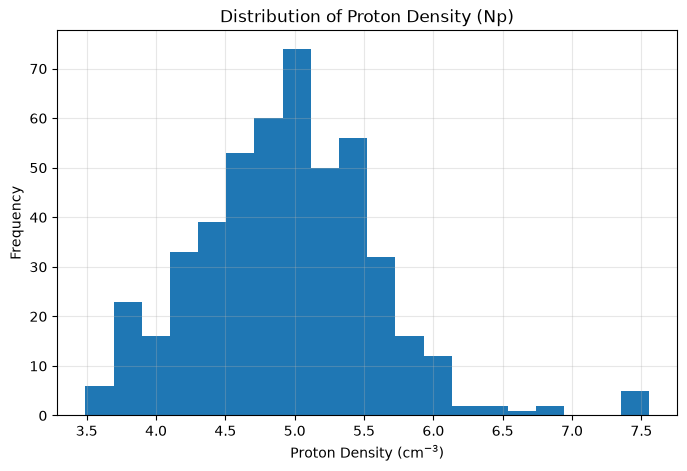

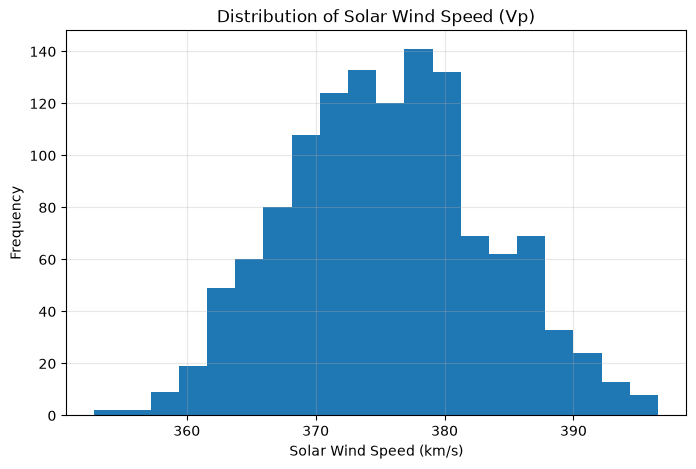

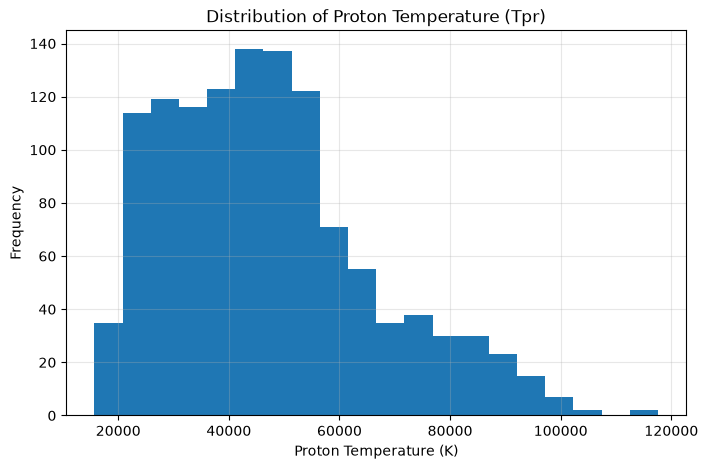

In [29]:
# Histogram of Np

plt.figure(figsize=(8,5))

plt.hist(np_valid, bins=20)

plt.title("Distribution of Proton Density (Np)")
plt.xlabel("Proton Density (cm$^{-3}$)")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

# Histogram of Vp

plt.figure(figsize=(8,5))

plt.hist(vp_valid, bins=20)

plt.title("Distribution of Solar Wind Speed (Vp)")
plt.xlabel("Solar Wind Speed (km/s)")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

# Histogram of Tpr

plt.figure(figsize=(8,5))

plt.hist(tpr_valid, bins=20)

plt.title("Distribution of Proton Temperature (Tpr)")
plt.xlabel("Proton Temperature (K)")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

# Histogram Interpretation

# Proton Density (Np)

The proton density distribution is centered around approximately 5 cm^-3 and is relatively narrow. Most valid measurements fall between about 4 and 5.5 cm^-3, with a small number of higher density observations extending toward 7.5 cm^-3. The distribution is approximately symmetric with a slight right tail.

# Solar Wind Speed (Vp)

Solar wind speed forms a compact distribution centered near 376 km/s. Most observations lie within a narrow range of approximately 365–385 km/s, indicating relatively steady solar wind conditions during this interval.

# Proton Temperature (Tpr)

Proton temperature exhibits the broadest distribution of the three variables. Most observations occur between approximately 20,000 K and 60,000 K, with a noticeable right tail extending beyond 100,000 K. This agrees with the statistical summary, where the mean exceeds the median, indicating occasional higher temperature events.

# Preliminary Conclusion

The three variables exhibit noticeably different statistical behavior. Proton density contains substantial invalid data despite having a relatively compact distribution among valid measurements. Solar wind speed is highly stable and occupies a narrow range of values, while proton temperature exhibits the greatest variability and a positively skewed distribution. These observations suggest that different preprocessing and normalization strategies may be required for each variable before meaningful sonification can be performed.



Last few investigations

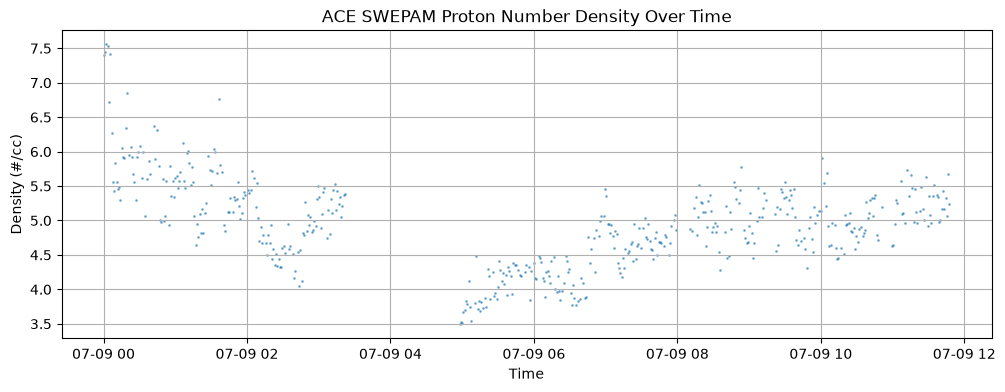

In [30]:
# Np scatter plot

plt.figure(figsize=(12, 4))
plt.scatter(time_np, np_valid, s=1, alpha=0.5)
plt.title("ACE SWEPAM Proton Number Density Over Time")
plt.xlabel("Time")
plt.ylabel(f"Density ({density_atts.get('UNITS', '')})")
plt.grid(True)


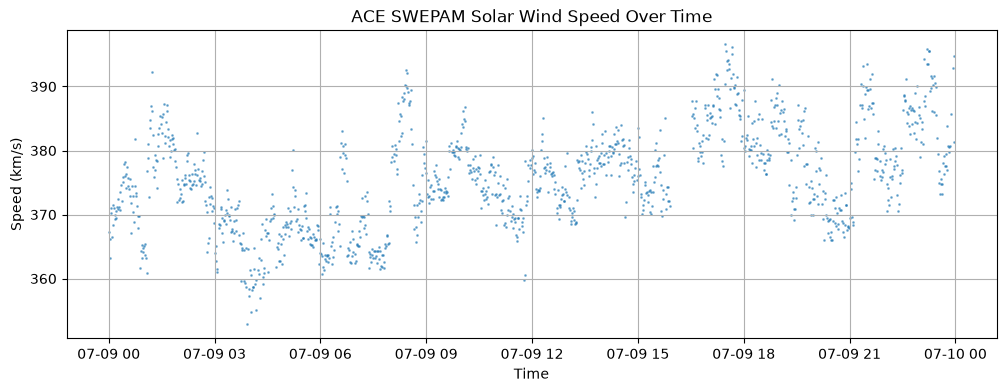

In [31]:
# Vp scatter plot

plt.figure(figsize=(12, 4))
plt.scatter(time_vp, vp_valid, s=1, alpha=0.5)
plt.title("ACE SWEPAM Solar Wind Speed Over Time")
plt.xlabel("Time")
plt.ylabel(f"Speed ({speed_atts.get('UNITS', '')})")
plt.grid(True)

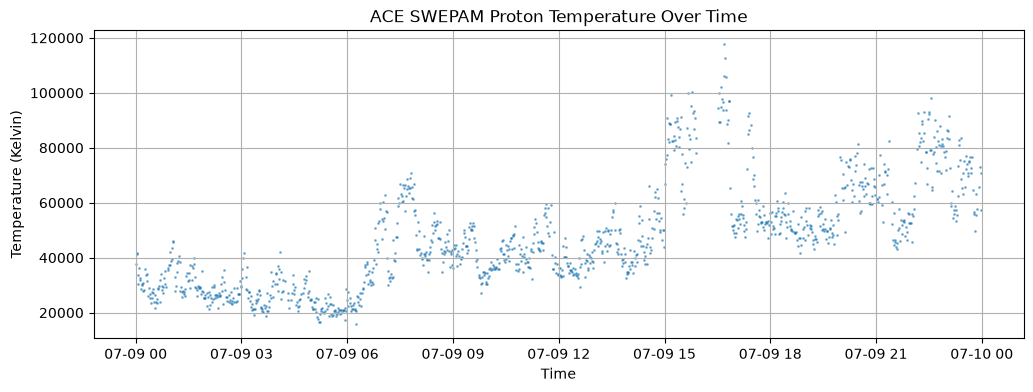

In [32]:
# Tpr scatter plot

plt.figure(figsize=(12, 4))
plt.scatter(time_tpr, tpr_valid, s=1, alpha=0.5)
plt.title("ACE SWEPAM Proton Temperature Over Time")
plt.xlabel("Time")
plt.ylabel(f"Temperature ({temperature_atts.get('UNITS', '')})")
plt.grid(True)

array([[1.        , 0.23070819],
       [0.23070819, 1.        ]])

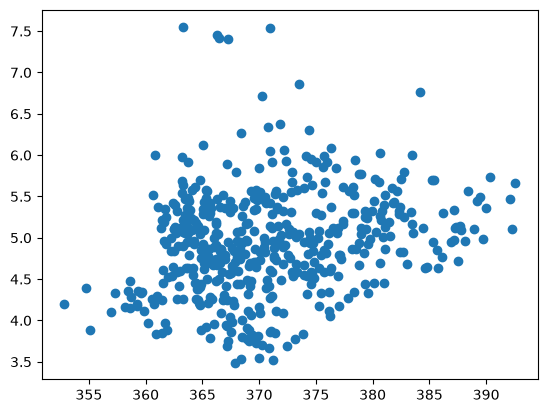

In [33]:
plt.scatter(vp_valid[:482],np_valid)

np.corrcoef(vp_valid[:482], np_valid)

# Variable Comparison Summary

## Raw Data Quality Summary

This table compares the raw CDF arrays before cleaning. Invalid samples include fill values, non-finite values, and values outside each variable's CDF `VALIDMIN` / `VALIDMAX` range.

| Variable | Units | Raw Samples | Invalid Samples | Invalid Data | Largest Invalid Gap | Data-Quality Notes |
|----------|-------|-------------|-----------------|------------------------|---------------------|--------------------|
| **Np** | cm^-3 | 1350 | 868 | 64.30% | 686 samples (~731.7 min) | Proton density has substantial invalid coverage and needs explicit invalid-interval handling before sonification. |
| **Vp** | km/s | 1350 | 93 | 6.89% | 34 samples (~36.3 min) | Solar wind speed has some invalid raw samples, but far fewer than density. |
| **Tpr** | K | 1350 | 138 | 10.22% | 34 samples (~36.3 min) | Proton temperature also has invalid raw samples that should be filtered before interpretation. |

## Cleaned Variable Summary

This table compares only valid samples after filtering out fill values and values outside the CDF valid range. These cleaned arrays are the appropriate basis for statistical interpretation and sonification planning.

| Variable | Units | Clean Samples | Clean Statistical Behavior | Distribution | Sonification Considerations |
|----------|-------|---------------|----------------------------|--------------|-----------------------------|
| **Np** | cm^-3 | 482 | Low variability (mean = 4.94, sigma = 0.64 cm^-3) | Approximately symmetric with a slight right tail | Scientifically valuable but limited by extensive invalid intervals. Could be used for secondary sonification parameters such as timbre or amplitude if invalid-interval handling strategies are implemented. |
| **Vp** | km/s | 1257 | Very low variability (mean = 375.60, sigma = 7.76 km/s) | Narrow, approximately symmetric | Continuous after cleaning but numerically compact. Normalization will likely be needed to make changes perceptible. |
| **Tpr** | K | 1212 | Highest variability (mean ~47,091 K, sigma ~18,754 K) | Right-skewed with occasional high-temperature events | Strong candidate for early sonification because its cleaned values have the broadest dynamic range. Nonlinear normalization may help preserve rare high-temperature events. |



# Notebook Conclusion

This notebook analyzed the primary ACE SWEPAM plasma variables in preparation for sonification while keeping raw data quality separate from cleaned-data interpretation.

The raw CDF comparison shows that proton density (`Np`) has the largest data-quality problem, with 868 invalid samples out of 1350 and one long invalid interval of about 731.7 minutes. Raw `Vp` and `Tpr` also contain invalid samples, but at much lower rates, so they should still be cleaned before scientific interpretation.

After cleaning, `Np` is relatively stable but sparse, `Vp` remains very steady over a narrow speed range, and `Tpr` exhibits the greatest variability with a positively skewed distribution. For sonification, `Tpr` is the strongest first candidate because it preserves a broad dynamic range after cleaning, while `Np` requires careful invalid-data handling and `Vp` likely needs normalization to make its small changes audible.

The next notebook will start normalization and preprocessing based on the cleaned variables and the raw data-quality constraints identified here.

